# Møller vortex packets — analysis workspace

This notebook is intended for day-to-day calculations based on the local `moller_vortex` package.

Use it for parameter scans, quick checks, plots, and comparisons between analytic and numerical expressions. The implementation itself lives in `src/moller_vortex/`; built-in check functions live in `src/moller_vortex/checks.py`; the detailed function guide is in `docs/FUNCTION_GUIDE.md`.


## 1. Imports and local package path

The cell below makes the local `src/` directory importable when the notebook is run from the project root. If the package has been installed with `pip install -e .`, this path setup is harmless.

In [1]:
import numpy as np
import moller_vortex as mv
import matplotlib.pyplot as plt

## 2. Numerical accuracy

All adaptive integrations use a `NumericalAccuracy` object. Keep accuracy parameters explicit in scans so that numerical settings are reproducible.

In [2]:
accuracy = mv.NumericalAccuracy(
    quad_epsabs=1.0e-10,
    quad_epsrel=1.0e-10,
    quad_limit= 30,
    root_residual_atol=1.0e-10,
)

accuracy


NumericalAccuracy(quad_epsabs=1e-10, quad_epsrel=1e-10, quad_limit=30, root_residual_atol=1e-10)

## 2.1 Built-in consistency checks

Run these when you want to check that the main analytic and numerical pieces still agree. They are ordinary functions, not a separate pytest suite.


In [3]:
check_results = mv.run_all_checks(
    accuracy=accuracy,
    n_phi=50,
    verbose=True,
)

Normalization errors
  spherical normalization, ell=0                0.000000e+00
  spherical normalization, ell=2                2.865063e-16
  spherical normalization, ell=-3               1.978304e-16
Laguerre-derivative errors
  Laguerre derivative, a=0, b=0                 0.000000e+00
  Laguerre derivative, a=0, b=3                 0.000000e+00
  Laguerre derivative, a=3, b=0                 0.000000e+00
  Laguerre derivative, a=1, b=4                 2.601311e-17
  Laguerre derivative, a=4, b=1                 6.462988e-17
  Laguerre derivative, a=3, b=3                 1.330882e-16
Transverse-integral errors
  transverse integral, ell1=1, ell2=2           1.125179e-14
  transverse integral, ell1=-1, ell2=-2         6.180452e-15
  transverse integral, ell1=1, ell2=-2          7.284584e-16
  transverse integral, ell1=-1, ell2=2          4.365855e-16
  transverse integral, ell1=0, ell2=2           1.022618e-16
  transverse integral, ell1=0, ell2=-2          5.595432e-16
  transver

## 3. Incoming packets and normalization

`LGPacket` contains only physical packet parameters. Normalization constants are computed explicitly by `normalization_constant`.

In [4]:
packet1 = mv.LGPacket(
    ell=1,
    sigma_perp=0.18,
    sigma_par=0.35,
    kbar_z=20.0,
)

packet2 = mv.LGPacket(
    ell=-1,
    sigma_perp=0.18,
    sigma_par=0.35,
    kbar_z=-20.0,
)

N1 = mv.normalization_constant(packet1, accuracy=accuracy)
N2 = mv.normalization_constant(packet2, accuracy=accuracy)

print("packet1 =", packet1)
print("packet2 =", packet2)
print("N1 =", N1)
print("N2 =", N2)

packet1 = LGPacket(ell=1, sigma_perp=0.18, sigma_par=0.35, kbar_z=20.0)
packet2 = LGPacket(ell=-1, sigma_perp=0.18, sigma_par=0.35, kbar_z=-20.0)
N1 = 64.5323735338619
N2 = 64.5323735338619


## 4. Final momenta, helicities, and impact parameter

All momenta are in MeV. The impact parameter is in MeV$^{-1}$. In the current convention the impact phase is applied only to the second incoming packet.

In [5]:
k3 = np.array([0.80, 0.10, 19.70])
k4 = np.array([-0.55, -0.08, -19.60])

impact_b = np.array([0.30, 0.00])

lam1 = 0.5
lam2 = 0.5
lam3 = 0.5
lam4 = 0.5

## 5. Closed impulse S-matrix

This is the main fast expression. It uses the analytic transverse integral.

In [6]:
S_closed = mv.S_impulse_closed_form(
    k3,
    k4,
    packet1,
    packet2,
    lam1=lam1,
    lam2=lam2,
    lam3=lam3,
    lam4=lam4,
    impact_b=impact_b,
    N1=N1,
    N2=N2,
    accuracy=accuracy,
)

S_closed

(0.00015242280451623416+0.01574217901924485j)

## 6. Numerical transverse check

This is slower. It replaces the analytic transverse integral by a direct numerical transverse integration, while keeping the same external prefactors. Use it as a check, not as the main production method.

In [7]:
S_numeric_transverse = mv.S_impulse_numeric_transverse_quad(
    k3,
    k4,
    packet1,
    packet2,
    lam1=lam1,
    lam2=lam2,
    lam3=lam3,
    lam4=lam4,
    impact_b=impact_b,
    N1=N1,
    N2=N2,
    n_phi=32,
    accuracy=accuracy,
)

print("S_closed             =", S_closed)
print("S_numeric_transverse =", S_numeric_transverse)
print("relative error       =", mv.relative_error(S_numeric_transverse, S_closed))

S_closed             = (0.00015242280451623416+0.01574217901924485j)
S_numeric_transverse = (0.0001524228045191255+0.015742179019263867j)
relative error       = 1.2217935776812517e-12


## 7. Scan over discrete OAM

Example scan over $\ell_1$ with all other parameters fixed.

In [8]:
ell_values = np.arange(-4, 5)
scan_ell = []

for ell in ell_values:
    p1 = mv.LGPacket(
        ell=int(ell),
        sigma_perp=packet1.sigma_perp,
        sigma_par=packet1.sigma_par,
        kbar_z=packet1.kbar_z,
    )
    Np1 = mv.normalization_constant(p1, accuracy=accuracy)
    S_ell = mv.S_impulse_closed_form(
        k3,
        k4,
        p1,
        packet2,
        lam1=lam1,
        lam2=lam2,
        lam3=lam3,
        lam4=lam4,
        impact_b=impact_b,
        N1=Np1,
        N2=N2,
        accuracy=accuracy,
    )
    scan_ell.append((ell, S_ell, abs(S_ell)))

for ell, S_ell, abs_S in scan_ell:
    print(f"ell1={ell:2d}  S={S_ell}  |S|={abs_S:.6e}")

ell1=-4  S=(-0.0007822121072453399-0.0015255569698802813j)  |S|=1.714404e-03
ell1=-3  S=(-0.0014885413509927413-0.00402822691759189j)  |S|=4.294458e-03
ell1=-2  S=(-0.002086916709741339-0.008772360228753518j)  |S|=9.017179e-03
ell1=-1  S=(-0.0016534990463088059-0.014684340444354555j)  |S|=1.477714e-02
ell1= 0  S=(0.00018067189992263845-0.015999371786495572j)  |S|=1.600039e-02
ell1= 1  S=(0.00015242280451623416+0.01574217901924485j)  |S|=1.574292e-02
ell1= 2  S=(-0.0021595223110001064+0.027914208457795138j)  |S|=2.799762e-02
ell1= 3  S=(-0.0029755979671599853+0.021794718055145785j)  |S|=2.199691e-02
ell1= 4  S=(-0.002275022670258299+0.011986170193102963j)  |S|=1.220016e-02


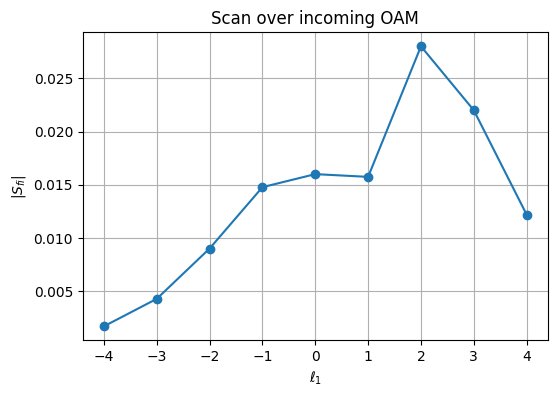

In [19]:
plt.figure(figsize=(6, 4))
plt.plot([row[0] for row in scan_ell], [row[2] for row in scan_ell], marker="o")
plt.xlabel(r"$\ell_1$")
plt.ylabel(r"$|S_{fi}|$")
plt.title("Scan over incoming OAM")
plt.grid(True)
plt.show()

## 8. Scan over continuous width parameter

Example scan over $\sigma_\perp$ for the first packet. The condition $\sigma_\perp \le \sigma_\parallel$ must be respected.

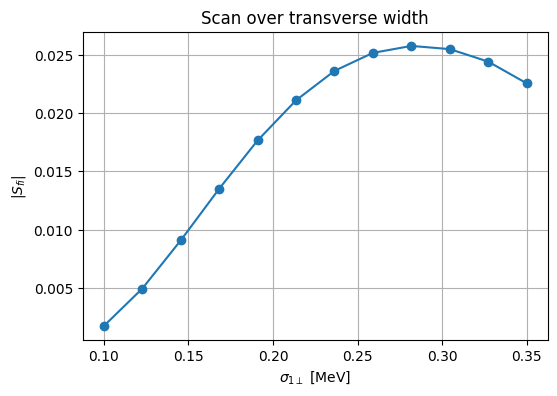

In [9]:
sigma_values = np.linspace(0.10, packet1.sigma_par, 12)
scan_sigma = []

for sigma_perp in sigma_values:
    p1 = mv.LGPacket(
        ell=packet1.ell,
        sigma_perp=float(sigma_perp),
        sigma_par=packet1.sigma_par,
        kbar_z=packet1.kbar_z,
    )
    Np1 = mv.normalization_constant(p1, accuracy=accuracy)
    S_sigma = mv.S_impulse_closed_form(
        k3,
        k4,
        p1,
        packet2,
        lam1=lam1,
        lam2=lam2,
        lam3=lam3,
        lam4=lam4,
        impact_b=impact_b,
        N1=Np1,
        N2=N2,
        accuracy=accuracy,
    )
    scan_sigma.append((sigma_perp, S_sigma, abs(S_sigma)))

plt.figure(figsize=(6, 4))
plt.plot([row[0] for row in scan_sigma], [row[2] for row in scan_sigma], marker="o")
plt.xlabel(r"$\sigma_{1\perp}$ [MeV]")
plt.ylabel(r"$|S_{fi}|$")
plt.title("Scan over transverse width")
plt.grid(True)
plt.show()

# Differential probability $w$ plot

In [ ]:
6.582119569 * 10**(-16) * 3 * 10**8 * 10**9 * 10**(-6) #hbar * c

0.00019746358706999997

## $b = 5$ nm

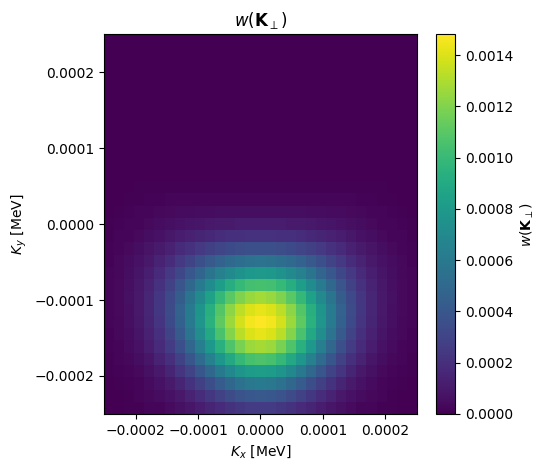

In [10]:
HBARC_MEV_NM = 1.97463e-4 #MeV * nm
NM_TO_MEV_INV = 1.0 / HBARC_MEV_NM 

def spatial_width_nm_to_momentum_mev(width_nm: float) -> float:
    return HBARC_MEV_NM / width_nm


sigma1_perp = spatial_width_nm_to_momentum_mev(10.0)
sigma2_perp = spatial_width_nm_to_momentum_mev(2.0)
sigma1_par = spatial_width_nm_to_momentum_mev(5.0)
sigma2_par = spatial_width_nm_to_momentum_mev(1.0)

impact_b = np.array([5.0 * NM_TO_MEV_INV, 0.0], dtype=float)

packet1 = mv.LGPacket(
    ell=5,
    sigma_perp=sigma1_perp,
    sigma_par=sigma1_par,
    kbar_z=10.0,
)

packet2 = mv.LGPacket(
    ell=0,
    sigma_perp=sigma2_perp,
    sigma_par=sigma2_par,
    kbar_z=-10.0,
)

N1 = mv.normalization_constant(packet1, accuracy=accuracy)
N2 = mv.normalization_constant(packet2, accuracy=accuracy)

quadrature = mv.ProbabilityQuadrature(
    k3_perp_range=(0.010, 0.050),
    k3z_range=(8.0, 12.0),
    k4z_range=(-12.0, -8.0),
    n_k3_perp=10,
    n_phi=24,
    n_k3z=10,
    n_k4z=10,
)

Kx_values = np.linspace(-0.00025, 0.00025, 31)
Ky_values = np.linspace(-0.00025, 0.00025, 31)

W = mv.diff_probability_grid(
    Kx_values,
    Ky_values,
    packet1,
    packet2,
    quadrature,
    impact_b=impact_b,
    N1=N1,
    N2=N2,
    accuracy=accuracy,
)

fig, ax = plt.subplots(figsize=(5.5, 4.8))

image = ax.imshow(
    W,
    origin="lower",
    extent=[
        Kx_values[0],
        Kx_values[-1],
        Ky_values[0],
        Ky_values[-1],
    ],
    aspect="auto",
)

ax.set_xlabel(r"$K_x$ [MeV]")
ax.set_ylabel(r"$K_y$ [MeV]")
ax.set_title(r"$w(\mathbf{K}_{\perp})$")

cbar = fig.colorbar(image, ax=ax)
cbar.set_label(r"$w(\mathbf{K}_{\perp})$")

fig.tight_layout()
plt.show()


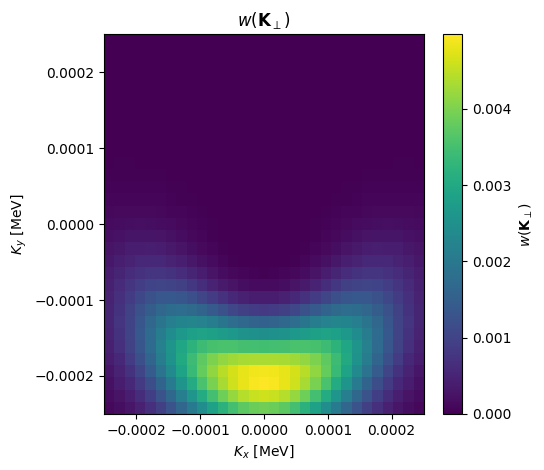

In [3]:
HBARC_MEV_NM = 1.97463e-4 #MeV * nm
NM_TO_MEV_INV = 1.0 / HBARC_MEV_NM 

def spatial_width_nm_to_momentum_mev(width_nm: float) -> float:
    return HBARC_MEV_NM / width_nm


sigma1_perp = spatial_width_nm_to_momentum_mev(10.0)
sigma2_perp = spatial_width_nm_to_momentum_mev(2.0)
sigma1_par = spatial_width_nm_to_momentum_mev(5.0)
sigma2_par = spatial_width_nm_to_momentum_mev(1.0)

impact_b = np.array([5.0 * NM_TO_MEV_INV, 0.0], dtype=float)

packet1 = mv.LGPacket(
    ell=5,
    sigma_perp=sigma1_perp,
    sigma_par=sigma1_par,
    kbar_z=10.0,
)

packet2 = mv.LGPacket(
    ell=2,
    sigma_perp=sigma2_perp,
    sigma_par=sigma2_par,
    kbar_z=-10.0,
)

N1 = mv.normalization_constant(packet1, accuracy=accuracy)
N2 = mv.normalization_constant(packet2, accuracy=accuracy)

quadrature = mv.ProbabilityQuadrature(
    k3_perp_range=(0.010, 0.050),
    k3z_range=(8.0, 12.0),
    k4z_range=(-12.0, -8.0),
    n_k3_perp=10,
    n_phi=24,
    n_k3z=10,
    n_k4z=10,
)

Kx_values = np.linspace(-0.00025, 0.00025, 31)
Ky_values = np.linspace(-0.00025, 0.00025, 31)

W = mv.diff_probability_grid(
    Kx_values,
    Ky_values,
    packet1,
    packet2,
    quadrature,
    impact_b=impact_b,
    N1=N1,
    N2=N2,
    accuracy=accuracy,
)

fig, ax = plt.subplots(figsize=(5.5, 4.8))

image = ax.imshow(
    W,
    origin="lower",
    extent=[
        Kx_values[0],
        Kx_values[-1],
        Ky_values[0],
        Ky_values[-1],
    ],
    aspect="auto",
)

ax.set_xlabel(r"$K_x$ [MeV]")
ax.set_ylabel(r"$K_y$ [MeV]")
ax.set_title(r"$w(\mathbf{K}_{\perp})$")

cbar = fig.colorbar(image, ax=ax)
cbar.set_label(r"$w(\mathbf{K}_{\perp})$")

fig.tight_layout()
plt.show()

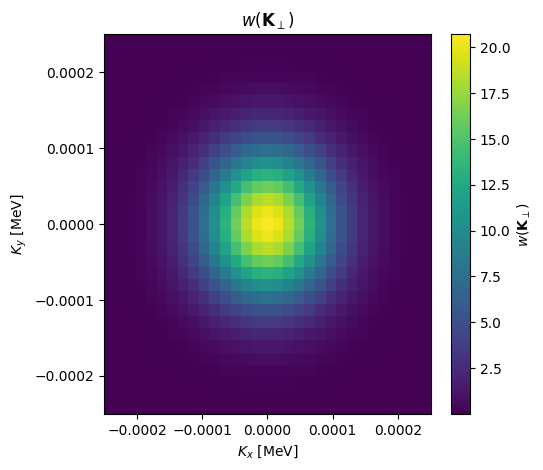

In [4]:
HBARC_MEV_NM = 1.97463e-4 #MeV * nm
NM_TO_MEV_INV = 1.0 / HBARC_MEV_NM 

def spatial_width_nm_to_momentum_mev(width_nm: float) -> float:
    return HBARC_MEV_NM / width_nm


sigma1_perp = spatial_width_nm_to_momentum_mev(10.0)
sigma2_perp = spatial_width_nm_to_momentum_mev(2.0)
sigma1_par = spatial_width_nm_to_momentum_mev(5.0)
sigma2_par = spatial_width_nm_to_momentum_mev(1.0)

impact_b = np.array([5.0 * NM_TO_MEV_INV, 0.0], dtype=float)

packet1 = mv.LGPacket(
    ell=0,
    sigma_perp=sigma1_perp,
    sigma_par=sigma1_par,
    kbar_z=10.0,
)

packet2 = mv.LGPacket(
    ell=0,
    sigma_perp=sigma2_perp,
    sigma_par=sigma2_par,
    kbar_z=-10.0,
)

N1 = mv.normalization_constant(packet1, accuracy=accuracy)
N2 = mv.normalization_constant(packet2, accuracy=accuracy)

quadrature = mv.ProbabilityQuadrature(
    k3_perp_range=(0.010, 0.050),
    k3z_range=(8.0, 12.0),
    k4z_range=(-12.0, -8.0),
    n_k3_perp=10,
    n_phi=24,
    n_k3z=10,
    n_k4z=10,
)

Kx_values = np.linspace(-0.00025, 0.00025, 31)
Ky_values = np.linspace(-0.00025, 0.00025, 31)

W = mv.diff_probability_grid(
    Kx_values,
    Ky_values,
    packet1,
    packet2,
    quadrature,
    impact_b=impact_b,
    N1=N1,
    N2=N2,
    accuracy=accuracy,
)

fig, ax = plt.subplots(figsize=(5.5, 4.8))

image = ax.imshow(
    W,
    origin="lower",
    extent=[
        Kx_values[0],
        Kx_values[-1],
        Ky_values[0],
        Ky_values[-1],
    ],
    aspect="auto",
)

ax.set_xlabel(r"$K_x$ [MeV]")
ax.set_ylabel(r"$K_y$ [MeV]")
ax.set_title(r"$w(\mathbf{K}_{\perp})$")

cbar = fig.colorbar(image, ax=ax)
cbar.set_label(r"$w(\mathbf{K}_{\perp})$")

fig.tight_layout()
plt.show()

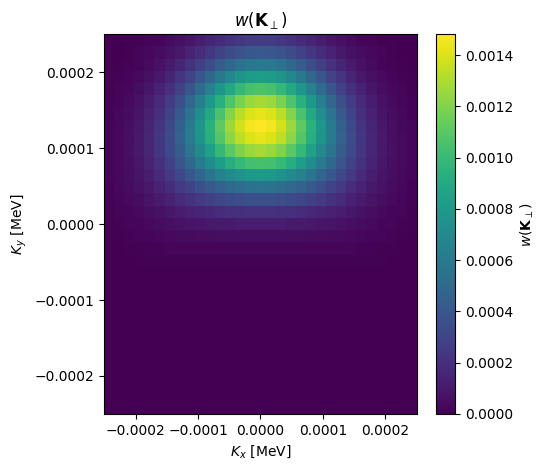

In [5]:
HBARC_MEV_NM = 1.97463e-4 #MeV * nm
NM_TO_MEV_INV = 1.0 / HBARC_MEV_NM 

def spatial_width_nm_to_momentum_mev(width_nm: float) -> float:
    return HBARC_MEV_NM / width_nm


sigma1_perp = spatial_width_nm_to_momentum_mev(10.0)
sigma2_perp = spatial_width_nm_to_momentum_mev(2.0)
sigma1_par = spatial_width_nm_to_momentum_mev(5.0)
sigma2_par = spatial_width_nm_to_momentum_mev(1.0)

impact_b = np.array([5.0 * NM_TO_MEV_INV, 0.0], dtype=float)

packet1 = mv.LGPacket(
    ell=-5,
    sigma_perp=sigma1_perp,
    sigma_par=sigma1_par,
    kbar_z=10.0,
)

packet2 = mv.LGPacket(
    ell=0,
    sigma_perp=sigma2_perp,
    sigma_par=sigma2_par,
    kbar_z=-10.0,
)

N1 = mv.normalization_constant(packet1, accuracy=accuracy)
N2 = mv.normalization_constant(packet2, accuracy=accuracy)

quadrature = mv.ProbabilityQuadrature(
    k3_perp_range=(0.010, 0.050),
    k3z_range=(8.0, 12.0),
    k4z_range=(-12.0, -8.0),
    n_k3_perp=10,
    n_phi=24,
    n_k3z=10,
    n_k4z=10,
)

Kx_values = np.linspace(-0.00025, 0.00025, 31)
Ky_values = np.linspace(-0.00025, 0.00025, 31)

W = mv.diff_probability_grid(
    Kx_values,
    Ky_values,
    packet1,
    packet2,
    quadrature,
    impact_b=impact_b,
    N1=N1,
    N2=N2,
    accuracy=accuracy,
)

fig, ax = plt.subplots(figsize=(5.5, 4.8))

image = ax.imshow(
    W,
    origin="lower",
    extent=[
        Kx_values[0],
        Kx_values[-1],
        Ky_values[0],
        Ky_values[-1],
    ],
    aspect="auto",
)

ax.set_xlabel(r"$K_x$ [MeV]")
ax.set_ylabel(r"$K_y$ [MeV]")
ax.set_title(r"$w(\mathbf{K}_{\perp})$")

cbar = fig.colorbar(image, ax=ax)
cbar.set_label(r"$w(\mathbf{K}_{\perp})$")

fig.tight_layout()
plt.show()

# Average $\langle K_y \rangle$

Integrated 1 out of 40 points: b_x = 0.000 nm, <Ky> = -1.017972e-13 eV
Integrated 2 out of 40 points: b_x = 0.167 nm, <Ky> = 4.026816e+01 eV
Integrated 3 out of 40 points: b_x = 0.333 nm, <Ky> = 7.586473e+01 eV
Integrated 4 out of 40 points: b_x = 0.500 nm, <Ky> = 1.041034e+02 eV
Integrated 5 out of 40 points: b_x = 0.667 nm, <Ky> = 1.246866e+02 eV
Integrated 6 out of 40 points: b_x = 0.833 nm, <Ky> = 1.387985e+02 eV
Integrated 7 out of 40 points: b_x = 1.000 nm, <Ky> = 1.480506e+02 eV
Integrated 8 out of 40 points: b_x = 1.167 nm, <Ky> = 1.538811e+02 eV
Integrated 9 out of 40 points: b_x = 1.333 nm, <Ky> = 1.573728e+02 eV
Integrated 10 out of 40 points: b_x = 1.500 nm, <Ky> = 1.592762e+02 eV
Integrated 11 out of 40 points: b_x = 1.667 nm, <Ky> = 1.600926e+02 eV
Integrated 12 out of 40 points: b_x = 1.833 nm, <Ky> = 1.601532e+02 eV
Integrated 13 out of 40 points: b_x = 2.000 nm, <Ky> = 1.596784e+02 eV
Integrated 14 out of 40 points: b_x = 2.167 nm, <Ky> = 1.588168e+02 eV
Integrated 15 

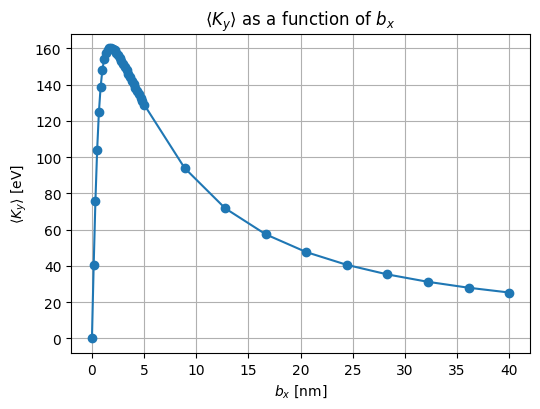

In [4]:
HBARC_MEV_NM = 1.97463e-4 #MeV * nm
NM_TO_MEV_INV = 1.0 / HBARC_MEV_NM 

def spatial_width_nm_to_momentum_mev(width_nm: float) -> float:
    return HBARC_MEV_NM / width_nm


sigma1_perp = spatial_width_nm_to_momentum_mev(10.0)
sigma2_perp = spatial_width_nm_to_momentum_mev(2.0)
sigma1_par = spatial_width_nm_to_momentum_mev(5.0)
sigma2_par = spatial_width_nm_to_momentum_mev(1.0)

impact_b = np.array([5.0 * NM_TO_MEV_INV, 0.0], dtype=float)

packet1 = mv.LGPacket(
    ell=-5,
    sigma_perp=sigma1_perp,
    sigma_par=sigma1_par,
    kbar_z=10.0,
)

packet2 = mv.LGPacket(
    ell=0,
    sigma_perp=sigma2_perp,
    sigma_par=sigma2_par,
    kbar_z=-10.0,
)

N1 = mv.normalization_constant(packet1, accuracy=accuracy)
N2 = mv.normalization_constant(packet2, accuracy=accuracy)

quadrature = mv.ProbabilityQuadrature(
    k3_perp_range=(0.010, 0.050),
    k3z_range=(
        10.0 - 10.0 * sigma1_par,
        10.0 + 10.0 * sigma1_par,
    ),
    k4z_range=(
        -10.0 - 10.0 * sigma2_par,
        -10.0 + 10.0 * sigma2_par,
    ),
    n_k3_perp=10,
    n_phi=24,
    n_k3z=10,
    n_k4z=10,

    # This is total final transverse momentum K_perp.
    # The relevant scale is eV, i.e. 1e-4 MeV.
    K_perp_range=(0.0, 3.0e-4),
    n_K_perp=10,
    n_K_phi=24,
)

b_x_nm = np.concatenate([
    np.linspace(0.0, 5.0, 30, endpoint=False),
    np.linspace(5.0, 40.0, 10),
])

average = []

for counter, b_nm in enumerate(b_x_nm, start=1):
    Ky_value = mv.Ky_average(
        packet1,
        packet2,
        quadrature,
        impact_b=np.array([b_nm * NM_TO_MEV_INV, 0.0], dtype=float),
        N1=N1,
        N2=N2,
        accuracy=accuracy,
    )

    average.append(Ky_value)

    print(
        f"Integrated {counter} out of {len(b_x_nm)} points: "
        f"b_x = {b_nm:.3f} nm, "
        f"<Ky> = {Ky_value * 1.0e6:.6e} eV",
        flush=True,
    )

average = np.array(average, dtype=float)

fig, ax = plt.subplots(figsize=(5.5, 4.2))

ax.plot(
    b_x_nm,
    average * 1.0e6,
    marker="o",
    linewidth=1.5,
)

ax.set_xlabel(r"$b_x$ [nm]")
ax.set_ylabel(r"$\langle K_y\rangle$ [eV]")
ax.set_title(r"$\langle K_y\rangle$ as a function of $b_x$")
ax.grid(True)

fig.tight_layout()
plt.show()